In [48]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML
from html import escape

file_path = Path("data/Venue Forecasts and Labour.xlsx")

def show_result_summary(
    title,
    purpose,
    output,
    interpretation=None,
    formula=None,
    note=None
):
    """
    Display a formatted explanation immediately before
    a table, chart, or other notebook result.
    """

    optional_sections = ""

    if formula:
        optional_sections += f"""
        <div class="summary-section">
            <div class="summary-label">Calculation</div>
            <div class="summary-text formula-box">
                {formula}
            </div>
        </div>
        """

    if interpretation:
        optional_sections += f"""
        <div class="summary-section">
            <div class="summary-label">How to interpret it</div>
            <div class="summary-text">
                {escape(interpretation)}
            </div>
        </div>
        """

    if note:
        optional_sections += f"""
        <div class="summary-note">
            <strong>Note:</strong> {escape(note)}
        </div>
        """

    summary_html = f"""
    <style>
        .result-summary-card {{
            font-family:
                -apple-system,
                BlinkMacSystemFont,
                "Segoe UI",
                Arial,
                sans-serif;

            border: 1px solid #dbe3ec;
            border-left: 5px solid #2563eb;
            border-radius: 10px;
            background: #f8fafc;
            padding: 16px 18px;
            margin: 12px 0 16px 0;
            color: #1e293b;
            box-shadow: 0 1px 3px rgba(15, 23, 42, 0.06);
        }}

        .summary-title {{
            font-size: 19px;
            font-weight: 750;
            color: #0f172a;
            margin-bottom: 12px;
        }}

        .summary-section {{
            margin-top: 9px;
        }}

        .summary-label {{
            font-size: 11px;
            font-weight: 750;
            color: #475569;
            text-transform: uppercase;
            letter-spacing: 0.05em;
            margin-bottom: 3px;
        }}

        .summary-text {{
            font-size: 14px;
            line-height: 1.55;
            color: #334155;
        }}

        .formula-box {{
            display: inline-block;
            padding: 7px 10px;
            background: #ffffff;
            border: 1px solid #e2e8f0;
            border-radius: 6px;
            font-family: monospace;
        }}

        .summary-note {{
            margin-top: 12px;
            padding: 9px 11px;
            background: #fff7ed;
            border: 1px solid #fed7aa;
            border-radius: 7px;
            color: #9a3412;
            font-size: 13px;
            line-height: 1.45;
        }}
    </style>

    <div class="result-summary-card">

        <div class="summary-title">
            {escape(title)}
        </div>

        <div class="summary-section">
            <div class="summary-label">What this analysis does</div>
            <div class="summary-text">
                {escape(purpose)}
            </div>
        </div>

        <div class="summary-section">
            <div class="summary-label">Result shown</div>
            <div class="summary-text">
                {escape(output)}
            </div>
        </div>

        {optional_sections}

    </div>
    """

    display(HTML(summary_html))

In [49]:
# B = Date, C = Venue, D = Actual Sales
actual = pd.read_excel(
    file_path,
    sheet_name="Actual Sales and Labour",
    usecols="B:D",
    header=None,
    names=["date", "venue", "actual_sales"],
    engine="openpyxl"
)
# ---------------------------------------------------------
# 1. Clean the data
# ---------------------------------------------------------
actual["date"] = pd.to_datetime(actual["date"], errors="coerce").dt.normalize()

actual["venue"] = (
    actual["venue"]
    .astype("string")
    .str.strip()
)

actual["actual_sales"] = pd.to_numeric(
    actual["actual_sales"],
    errors="coerce"
)

# Remove invalid rows and rows without actual sales
# This automatically removes Contact Centre because its sales are blank
actual = actual.dropna(
    subset=["date", "venue", "actual_sales"]
).copy()

actual = actual[actual["venue"] != ""]

# ---------------------------------------------------------
# 2. Create one sales value per venue per date
# ---------------------------------------------------------
# If a venue/date appears more than once, sales are added together first.
daily_sales = (
    actual
    .groupby(["venue", "date"], as_index=False)
    .agg(actual_sales=("actual_sales", "sum"))
)

# ---------------------------------------------------------
# 3. Summarise each venue
# ---------------------------------------------------------
summary = (
    daily_sales
    .groupby("venue", as_index=False)
    .agg(
        total_actual_sales=("actual_sales", "sum"),
        mean_sales_per_day=("actual_sales", "mean"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        days_with_sales=("date", "nunique")
    )
)

# Number of calendar days from the venue's first date to last date
summary["calendar_days_in_range"] = (
    summary["end_date"] - summary["start_date"]
).dt.days + 1

# Readable date-range column
summary["date_range"] = (
    summary["start_date"].dt.strftime("%d %b %Y")
    + " – "
    + summary["end_date"].dt.strftime("%d %b %Y")
)

# Sort by mean daily sales, highest first
summary = (
    summary
    .sort_values(
        by="mean_sales_per_day",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking
summary.insert(0, "rank", range(1, len(summary) + 1))

# Final column order
summary = summary[
    [
        "rank",
        "venue",
        "total_actual_sales",
        "mean_sales_per_day",
        "date_range",
        "days_with_sales"
    ]
]

# ---------------------------------------------------------
# 4. Display formatted result
# ---------------------------------------------------------

show_result_summary(
    title="Actual Sales by Venue",
    purpose=(
        "Summarises actual sales for each venue after cleaning "
        "invalid records and combining duplicate venue-date entries."
    ),
    output=(
        "Total actual sales, mean sales per day, reporting date "
        "range and the number of days with valid sales data."
    ),
    interpretation=(
        "The table is ranked by mean daily sales from highest to "
        "lowest. A higher position indicates stronger average "
        "daily sales during the available period."
    ),
    note=(
        "Missing venue-date records are not automatically treated "
        "as zero sales."
    )
)
display(
    summary.style
    .format(
        {
            "total_actual_sales": "${:,.0f}",
            "mean_sales_per_day": "${:,.2f}"
        }
    )
    .hide(axis="index")
)

rank,venue,total_actual_sales,mean_sales_per_day,date_range,days_with_sales
1,Joondalup,"$776,902","$25,061.35",04 Jul 2025 – 03 Aug 2025,31
2,Greenacres,"$763,978","$24,644.45",04 Jul 2025 – 03 Aug 2025,31
3,Heidelberg,"$693,476","$22,370.19",04 Jul 2025 – 03 Aug 2025,31
4,Cannington,"$676,490","$21,822.26",04 Jul 2025 – 03 Aug 2025,31
5,Osborne Park,"$640,165","$21,338.83",04 Jul 2025 – 02 Aug 2025,30
6,Keysborough,"$593,146","$19,133.74",04 Jul 2025 – 03 Aug 2025,31
7,Homebush,"$525,895","$16,964.35",04 Jul 2025 – 03 Aug 2025,31
8,Gold Coast,"$521,945","$16,836.94",04 Jul 2025 – 03 Aug 2025,31
9,Adelaide,"$499,470","$16,649.00",04 Jul 2025 – 02 Aug 2025,30
10,Macgregor,"$481,652","$16,055.07",04 Jul 2025 – 02 Aug 2025,30


In [50]:
# B = Date, C = Venue, E = Actual Labour
labour = pd.read_excel(
    file_path,
    sheet_name="Actual Sales and Labour",
    usecols="B,C,E",
    header=None,
    names=["date", "venue", "actual_labour"],
    engine="openpyxl"
)

# ---------------------------------------------------------
# 1. Clean the data
# ---------------------------------------------------------
labour["date"] = pd.to_datetime(
    labour["date"],
    errors="coerce"
).dt.normalize()

labour["venue"] = (
    labour["venue"]
    .astype("string")
    .str.strip()
)

labour["actual_labour"] = pd.to_numeric(
    labour["actual_labour"],
    errors="coerce"
)

# Remove invalid or blank records
labour = labour.dropna(
    subset=["date", "venue", "actual_labour"]
).copy()

labour = labour[labour["venue"] != ""]

# ---------------------------------------------------------
# 2. Create one labour value per venue per date
# ---------------------------------------------------------
# If a venue/date appears more than once, labour is added together.
daily_labour = (
    labour
    .groupby(["venue", "date"], as_index=False)
    .agg(actual_labour=("actual_labour", "sum"))
)

# ---------------------------------------------------------
# 3. Summarise each venue
# ---------------------------------------------------------
labour_summary = (
    daily_labour
    .groupby("venue", as_index=False)
    .agg(
        total_actual_labour=("actual_labour", "sum"),
        mean_labour_per_day=("actual_labour", "mean"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        days_with_labour=("date", "nunique")
    )
)

# Create one readable date-range column
labour_summary["date_range"] = (
    labour_summary["start_date"].dt.strftime("%d %b %Y")
    + " – "
    + labour_summary["end_date"].dt.strftime("%d %b %Y")
)

# Sort by mean daily labour, highest first
labour_summary = (
    labour_summary
    .sort_values(
        "mean_labour_per_day",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking
labour_summary.insert(
    0,
    "rank",
    range(1, len(labour_summary) + 1)
)

# Keep only required columns
labour_summary = labour_summary[
    [
        "rank",
        "venue",
        "total_actual_labour",
        "mean_labour_per_day",
        "date_range",
        "days_with_labour"
    ]
]

# ---------------------------------------------------------
# 4. Display result
# ---------------------------------------------------------
show_result_summary(
    title="Actual Labour by Venue",
    purpose=(
        "Summarises actual labour expenditure for each venue after "
        "cleaning the data and combining duplicate venue-date records."
    ),
    output=(
        "Total actual labour, mean labour per day, reporting date "
        "range and number of valid labour days."
    ),
    interpretation=(
        "The ranking shows which venues incurred the highest average "
        "daily labour cost during the period."
    ),
    note=(
        "This table shows labour cost only. It does not account for "
        "differences in venue sales volume."
    )
)

display(
    labour_summary.style
    .format(
        {
            "total_actual_labour": "{:,.2f}",
            "mean_labour_per_day": "{:,.2f}"
        }
    )
    .hide(axis="index")
)

rank,venue,total_actual_labour,mean_labour_per_day,date_range,days_with_labour
1,Heidelberg,"135,421.00","4,368.42",04 Jul 2025 – 03 Aug 2025,31
2,Joondalup,"130,257.00","4,201.84",04 Jul 2025 – 03 Aug 2025,31
3,Gold Coast,"122,488.00","3,951.23",04 Jul 2025 – 03 Aug 2025,31
4,Osborne Park,"112,975.00","3,765.83",04 Jul 2025 – 02 Aug 2025,30
5,Greenacres,"115,185.00","3,715.65",04 Jul 2025 – 03 Aug 2025,31
6,Keysborough,"111,236.00","3,588.26",04 Jul 2025 – 03 Aug 2025,31
7,Cannington,"109,607.00","3,535.71",04 Jul 2025 – 03 Aug 2025,31
8,Homebush,"102,207.00","3,406.90",04 Jul 2025 – 03 Aug 2025,30
9,Macgregor,"94,147.00","3,138.23",04 Jul 2025 – 02 Aug 2025,30
10,Adelaide,"93,992.00","3,133.07",04 Jul 2025 – 02 Aug 2025,30


In [51]:
# Booking_archive columns:
# A = Date
# B = Venue Name
# C = Parties
# D = Programs
# E = Schools and Groups
booking = pd.read_excel(
    file_path,
    sheet_name="Booking_archive",
    usecols="A:E",
    engine="openpyxl"
)

# ---------------------------------------------------------
# 1. Rename and clean columns
# ---------------------------------------------------------
booking.columns = [
    "date",
    "venue",
    "parties",
    "programs",
    "schools_groups"
]

def convert_mixed_excel_dates(series):
    result = pd.Series(
        pd.NaT,
        index=series.index,
        dtype="datetime64[ns]"
    )

    # Detect numeric Excel serial dates
    numeric_dates = pd.to_numeric(series, errors="coerce")

    # Reasonable range for modern Excel dates
    excel_date_mask = numeric_dates.between(20000, 60000)

    # Convert Excel serial dates using Excel's date origin
    result.loc[excel_date_mask] = (
        pd.Timestamp("1899-12-30")
        + pd.to_timedelta(
            numeric_dates.loc[excel_date_mask],
            unit="D"
        )
    )

    # Convert existing text/datetime values normally
    normal_date_mask = numeric_dates.isna() & series.notna()

    result.loc[normal_date_mask] = pd.to_datetime(
        series.loc[normal_date_mask],
        errors="coerce"
    )

    return result.dt.normalize()


booking["date"] = convert_mixed_excel_dates(
    booking["date"]
)

booking["venue"] = (
    booking["venue"]
    .astype("string")
    .str.strip()
)

booking_columns = [
    "parties",
    "programs",
    "schools_groups"
]

# Convert booking columns to numbers.
# Blank booking categories become zero.
for column in booking_columns:
    booking[column] = pd.to_numeric(
        booking[column],
        errors="coerce"
    ).fillna(0)

# Remove rows without a valid date or venue
booking = booking.dropna(
    subset=["date", "venue"]
).copy()

booking = booking[booking["venue"] != ""]

# Total booking value for each row
booking["total_booking"] = (
    booking["parties"]
    + booking["programs"]
    + booking["schools_groups"]
)

# ---------------------------------------------------------
# 2. Create one booking value per venue per date
# ---------------------------------------------------------
daily_booking = (
    booking
    .groupby(["venue", "date"], as_index=False)
    .agg(
        parties=("parties", "sum"),
        programs=("programs", "sum"),
        schools_groups=("schools_groups", "sum"),
        total_booking=("total_booking", "sum")
    )
)

# ---------------------------------------------------------
# 3. Summarise each venue
# ---------------------------------------------------------
booking_summary = (
    daily_booking
    .groupby("venue", as_index=False)
    .agg(
        total_booking=("total_booking", "sum"),
        total_parties=("parties", "sum"),
        total_programs=("programs", "sum"),
        total_schools_groups=("schools_groups", "sum"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        days=("date", "nunique"),

        # Days where total booking is greater than zero
        valid_days=(
            "total_booking",
            lambda values: (values > 0).sum()
        )
    )
)

# All means use total recorded days, including zero-booking days
booking_summary["mean_booking_per_day"] = (
    booking_summary["total_booking"]
    / booking_summary["days"]
)

booking_summary["mean_parties"] = (
    booking_summary["total_parties"]
    / booking_summary["days"]
)

booking_summary["mean_programs"] = (
    booking_summary["total_programs"]
    / booking_summary["days"]
)

booking_summary["mean_schools_groups"] = (
    booking_summary["total_schools_groups"]
    / booking_summary["days"]
)

# Create readable date range
booking_summary["date_range"] = (
    booking_summary["start_date"].dt.strftime("%d %b %Y")
    + " – "
    + booking_summary["end_date"].dt.strftime("%d %b %Y")
)

# Sort by mean total booking, highest first
booking_summary = (
    booking_summary
    .sort_values(
        "mean_booking_per_day",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking
booking_summary.insert(
    0,
    "rank",
    range(1, len(booking_summary) + 1)
)

# Final columns
booking_summary = booking_summary[
    [
        "rank",
        "venue",
        "total_booking",
        "mean_booking_per_day",
        "date_range",
        "days",
        "valid_days",
        "mean_parties",
        "mean_programs",
        "mean_schools_groups"
    ]
]

# ---------------------------------------------------------
# 4. Display result
# ---------------------------------------------------------

show_result_summary(
    title="Booking Performance by Venue",
    purpose=(
        "Combines Parties, Programs, and Schools and Groups booking "
        "revenue and summarises booking performance for each venue."
    ),
    output=(
        "Total booking revenue, mean booking revenue per day, date "
        "range, total days, valid booking days, and average revenue "
        "from each booking category."
    ),
    formula=(
        "Mean booking per day = Total booking revenue ÷ All recorded days"
    ),
    interpretation=(
        "Valid days are dates with positive booking revenue. Mean "
        "booking revenue still uses all recorded days, including "
        "zero-booking days."
    )
)

display(
    booking_summary.style
    .format(
        {
            "total_booking": "${:,.2f}",
            "mean_booking_per_day": "${:,.2f}",
            "mean_parties": "${:,.2f}",
            "mean_programs": "${:,.2f}",
            "mean_schools_groups": "${:,.2f}"
        }
    )
    .hide(axis="index")
)


rank,venue,total_booking,mean_booking_per_day,date_range,days,valid_days,mean_parties,mean_programs,mean_schools_groups
1,Keysborough,"$209,916.00","$5,673.41",01 Jul 2025 – 24 Aug 2025,37,37,"$4,159.92",$15.81,"$1,497.68"
2,Homebush,"$193,958.00","$5,541.66",01 Jul 2025 – 24 Aug 2025,35,35,"$3,903.37",$78.71,"$1,559.57"
3,Greenacres,"$212,266.00","$5,442.72",01 Jul 2025 – 24 Aug 2025,39,39,"$3,859.41",$10.00,"$1,573.31"
4,Marleston,"$198,071.00","$4,951.77",01 Jul 2025 – 24 Aug 2025,40,40,"$3,548.43",$47.12,"$1,356.22"
5,Osborne Park,"$172,985.00","$4,805.14",01 Jul 2025 – 24 Aug 2025,36,35,"$3,728.44",$39.72,"$1,036.97"
6,Essendon,"$184,053.00","$4,719.31",01 Jul 2025 – 24 Aug 2025,39,39,"$3,438.21",$21.67,"$1,259.44"
7,Joondalup,"$177,208.00","$4,663.37",01 Jul 2025 – 24 Aug 2025,38,38,"$3,561.21",$15.39,"$1,086.76"
8,Heidelberg,"$210,337.00","$4,292.59",01 Jul 2025 – 24 Aug 2025,49,49,"$2,833.92",$26.53,"$1,432.14"
9,Blackburn,"$148,631.00","$4,017.05",01 Jul 2025 – 24 Aug 2025,37,37,"$2,918.14",$22.84,"$1,076.08"
10,Cannington,"$169,535.00","$3,853.07",01 Jul 2025 – 24 Aug 2025,44,39,"$2,610.32",$38.41,"$1,204.34"


In [52]:
# Read the separate F&B lookup worksheet
fb_table = pd.read_excel(
    file_path,
    sheet_name="F&B Lookup",
    usecols="A:B",
    engine="openpyxl"
)

# Rename columns
fb_table.columns = [
    "venue",
    "f_and_b_pct"
]

# Clean venue names and percentages
fb_table["venue"] = (
    fb_table["venue"]
    .astype("string")
    .str.strip()
)

fb_table["f_and_b_pct"] = pd.to_numeric(
    fb_table["f_and_b_pct"],
    errors="coerce"
)

# Remove blank rows
fb_table = fb_table.dropna(
    subset=["venue", "f_and_b_pct"]
).copy()

# Optional: change Adelaide to Marleston
fb_table["venue"] = fb_table["venue"].replace({
    "Adelaide": "Marleston"
})

# Sort from highest F&B percentage to lowest
fb_table = (
    fb_table
    .sort_values(
        "f_and_b_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add rank
fb_table.insert(
    0,
    "rank",
    range(1, len(fb_table) + 1)
)
show_result_summary(
    title="Food and Beverage Percentage by Venue",
    purpose=(
        "Displays the venue-level food and beverage percentages "
        "stored in the workbook's F&B lookup table."
    ),
    output=(
        "Each venue's F&B percentage, ranked from highest to lowest."
    ),
    interpretation=(
        "A higher percentage means a larger assumed share of venue "
        "revenue is attributed to food and beverage."
    ),
    note=(
        "These values are stored lookup assumptions. The workbook "
        "does not provide enough information to confirm how the "
        "percentages were originally calculated."
    )
)
display(
    fb_table.style
    .format({
        "f_and_b_pct": "{:.0%}"
    })
    .hide(axis="index")
)

rank,venue,f_and_b_pct
1,Carindale,26%
2,Hobart,22%
3,Morayfield,19%
4,Osborne Park,17%
5,Geelong,17%
6,Macgregor,17%
7,Wodonga,16%
8,Cromer,16%
9,Joondalup,16%
10,Homebush,16%


In [53]:
# =========================================================
# 1. Use the same venue-date period as labour comparison
# =========================================================
labour_comparison = (
    comparison[
        [
            "venue",
            "date",
            forecast_allowance_column,
            "ento_roster"
        ]
    ]
    .rename(
        columns={
            forecast_allowance_column:
                "forecast_labour_allowance",

            "ento_roster":
                "ento_labour"
        }
    )
    .merge(
        actual_labour,
        on=[
            "venue",
            "date"
        ],
        how="inner"
    )
)

period_scope = (
    labour_comparison[
        ["venue", "date"]
    ]
    .drop_duplicates()
    .copy()
)

period_start = period_scope["date"].min()
period_end = period_scope["date"].max()

print(
    "Booking share period:",
    period_start.strftime("%d %b %Y"),
    "to",
    period_end.strftime("%d %b %Y")
)


# =========================================================
# 2. Read booking data
# =========================================================
# Booking_archive:
# A = Date
# B = Venue
# C = Parties
# D = Programs
# E = Schools and Groups

booking_share_data = pd.read_excel(
    file_path,
    sheet_name="Booking_archive",
    usecols="A:E",
    engine="openpyxl"
)

booking_share_data.columns = [
    "date",
    "venue",
    "parties",
    "programs",
    "schools_groups"
]


# =========================================================
# 3. Clean booking data
# =========================================================
def clean_venue(series):
    """
    Standardise venue names used differently in the workbook.
    """
    return (
        series
        .astype("string")
        .str.strip()
        .replace(
            {
                "MacGregor": "Macgregor",
                "Marleston": "Adelaide"
            }
        )
    )


booking_share_data["date"] = convert_mixed_excel_dates(
    booking_share_data["date"]
)

booking_share_data["venue"] = clean_venue(
    booking_share_data["venue"]
)

booking_columns = [
    "parties",
    "programs",
    "schools_groups"
]

for column in booking_columns:
    booking_share_data[column] = pd.to_numeric(
        booking_share_data[column],
        errors="coerce"
    ).fillna(0)

booking_share_data = booking_share_data.dropna(
    subset=[
        "date",
        "venue"
    ]
).copy()

booking_share_data = booking_share_data[
    booking_share_data["venue"] != ""
]

booking_share_data["total_booking"] = (
    booking_share_data["parties"]
    + booking_share_data["programs"]
    + booking_share_data["schools_groups"]
)


# =========================================================
# 4. Create one booking record per venue and date
# =========================================================
daily_booking_share = (
    booking_share_data
    .groupby(
        ["venue", "date"],
        as_index=False
    )
    .agg(
        parties=("parties", "sum"),
        programs=("programs", "sum"),
        schools_groups=("schools_groups", "sum"),
        total_booking=("total_booking", "sum")
    )
)


# =========================================================
# 5. Restrict bookings to the same comparison period
# =========================================================
# Left merge ensures venues and dates with no booking
# are retained and treated as zero.

booking_period_data = (
    period_scope
    .merge(
        daily_booking_share,
        on=[
            "venue",
            "date"
        ],
        how="left"
    )
)

booking_period_data[
    [
        "parties",
        "programs",
        "schools_groups",
        "total_booking"
    ]
] = booking_period_data[
    [
        "parties",
        "programs",
        "schools_groups",
        "total_booking"
    ]
].fillna(0)


# =========================================================
# 6. Summarise booking value for each venue
# =========================================================
booking_share_summary = (
    booking_period_data
    .groupby(
        "venue",
        as_index=False
    )
    .agg(
        total_booking=("total_booking", "sum"),
        parties=("parties", "sum"),
        programs=("programs", "sum"),
        schools_groups=("schools_groups", "sum"),
        days=("date", "nunique"),
        valid_booking_days=(
            "total_booking",
            lambda values: (values > 0).sum()
        )
    )
)


# =========================================================
# 7. Calculate each venue's share
# =========================================================
network_total_booking = (
    booking_share_summary["total_booking"].sum()
)

if network_total_booking == 0:
    booking_share_summary["booking_share"] = np.nan
else:
    booking_share_summary["booking_share"] = (
        booking_share_summary["total_booking"]
        / network_total_booking
    )


# =========================================================
# 8. Sort descending and add rank
# =========================================================
booking_share_summary = (
    booking_share_summary
    .sort_values(
        "booking_share",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)

booking_share_summary.insert(
    0,
    "rank",
    range(1, len(booking_share_summary) + 1)
)


# =========================================================
# 9. Final table
# =========================================================
booking_share_summary = booking_share_summary[
    [
        "rank",
        "venue",
        "total_booking",
        "booking_share",
        "parties",
        "programs",
        "schools_groups",
        "days",
        "valid_booking_days"
    ]
]
show_result_summary(
    title="Booking Share by Venue",
    purpose=(
        "Measures each venue's contribution to total network booking "
        "revenue during the selected comparison period."
    ),
    output=(
        "Total booking revenue and booking share for every venue, "
        "ranked from highest to lowest."
    ),
    formula=(
        "Booking share = Venue booking revenue ÷ Total network booking revenue"
    ),
    interpretation=(
        "For example, a booking share of 8% means the venue generated "
        "8% of all booking revenue included in the analysis."
    ),
    note=(
        "Venue-date records without a booking are treated as zero "
        "within the selected comparison period."
    )
)
display(
    booking_share_summary.style
    .format(
        {
            "total_booking": "${:,.0f}",
            "booking_share": "{:.1%}",
            "parties": "${:,.0f}",
            "programs": "${:,.0f}",
            "schools_groups": "${:,.0f}"
        },
        na_rep="—"
    )
    .hide(axis="index")
)

Booking share period: 04 Jul 2025 to 03 Aug 2025


rank,venue,total_booking,booking_share,parties,programs,schools_groups,days,valid_booking_days
1,Greenacres,"$156,321",8.0%,"$104,798",$390,"$51,133",31,25
2,Keysborough,"$152,368",7.8%,"$105,882",$585,"$45,901",31,23
3,Homebush,"$144,204",7.4%,"$92,942","$2,136","$49,126",30,24
4,Heidelberg,"$142,711",7.3%,"$92,645","$1,300","$48,766",31,27
5,Adelaide,"$140,120",7.2%,"$98,461","$1,885","$39,774",30,27
6,Essendon,"$131,700",6.7%,"$86,905",$845,"$43,950",31,25
7,Joondalup,"$124,667",6.4%,"$91,787",$585,"$32,295",31,25
8,Osborne Park,"$117,898",6.0%,"$88,935","$1,430","$27,533",30,23
9,Cannington,"$116,941",6.0%,"$81,269","$1,690","$33,982",31,23
10,Blackburn,"$103,440",5.3%,"$70,526",$845,"$32,069",31,21


In [54]:
import numpy as np

# B = Date
# C = Venue
# D = Actual Sales
# E = Actual Labour
ratio_data = pd.read_excel(
    file_path,
    sheet_name="Actual Sales and Labour",
    usecols="B:E",
    header=None,
    names=[
        "date",
        "venue",
        "actual_sales",
        "actual_labour"
    ],
    engine="openpyxl"
)

# ---------------------------------------------------------
# 1. Clean the data
# ---------------------------------------------------------
ratio_data["date"] = pd.to_datetime(
    ratio_data["date"],
    errors="coerce"
).dt.normalize()

ratio_data["venue"] = (
    ratio_data["venue"]
    .astype("string")
    .str.strip()
)

ratio_data["actual_sales"] = pd.to_numeric(
    ratio_data["actual_sales"],
    errors="coerce"
)

ratio_data["actual_labour"] = pd.to_numeric(
    ratio_data["actual_labour"],
    errors="coerce"
)

# Remove rows without date, venue, sales or labour
ratio_data = ratio_data.dropna(
    subset=[
        "date",
        "venue",
        "actual_sales",
        "actual_labour"
    ]
).copy()

ratio_data = ratio_data[ratio_data["venue"] != ""]

# ---------------------------------------------------------
# 2. Combine duplicate venue-date rows
# ---------------------------------------------------------
daily_ratio = (
    ratio_data
    .groupby(
        ["venue", "date"],
        as_index=False
    )
    .agg(
        actual_sales=("actual_sales", "sum"),
        actual_labour=("actual_labour", "sum")
    )
)

# ---------------------------------------------------------
# 3. Calculate daily labour/sales ratio
# ---------------------------------------------------------
# Ratios cannot be calculated where sales are zero or negative.
daily_ratio["labour_sales_ratio"] = np.where(
    daily_ratio["actual_sales"] > 0,
    daily_ratio["actual_labour"]
    / daily_ratio["actual_sales"],
    np.nan
)

# ---------------------------------------------------------
# 4. Summarise each venue
# ---------------------------------------------------------
ratio_summary = (
    daily_ratio
    .groupby("venue", as_index=False)
    .agg(
        mean_ratio=(
            "labour_sales_ratio",
            "mean"
        ),
        max_ratio=(
            "labour_sales_ratio",
            "max"
        ),
        min_ratio=(
            "labour_sales_ratio",
            "min"
        ),
        greater_than_1_days=(
            "labour_sales_ratio",
            lambda values: (values > 1).sum()
        ),
        valid_ratio_days=(
            "labour_sales_ratio",
            "count"
        ),
        start_date=(
            "date",
            "min"
        ),
        end_date=(
            "date",
            "max"
        )
    )
)

# Create combined date-range column
ratio_summary["date_range"] = (
    ratio_summary["start_date"].dt.strftime("%d %b %Y")
    + " – "
    + ratio_summary["end_date"].dt.strftime("%d %b %Y")
)

# Sort by mean ratio descending
ratio_summary = (
    ratio_summary
    .sort_values(
        "mean_ratio",
        ascending=True
    )
    .reset_index(drop=True)
)

# Add rank
ratio_summary.insert(
    0,
    "rank",
    range(1, len(ratio_summary) + 1)
)

# Keep requested columns only
ratio_summary = ratio_summary[
    [
        "rank",
        "venue",
        "mean_ratio",
        "max_ratio",
        "min_ratio",
        "greater_than_1_days",
        "valid_ratio_days",
        "date_range"
    ]
]

# ---------------------------------------------------------
# 5. Display as percentages
# ---------------------------------------------------------
show_result_summary(
    title="Labour-to-Sales Ratio by Venue",
    purpose=(
        "Measures actual labour cost relative to actual sales for "
        "each venue on a daily basis."
    ),
    output=(
        "Mean, maximum and minimum labour-to-sales ratios, together "
        "with the number of days above 100% and valid ratio days."
    ),
    formula=(
        "Daily labour-to-sales ratio = Actual labour ÷ Actual sales"
    ),
    interpretation=(
        "A ratio of 25% means labour cost was equal to 25% of sales. "
        "A ratio above 100% means labour cost exceeded sales on that day."
    ),
    note=(
        "Days with zero or negative sales are excluded because the "
        "ratio cannot be meaningfully calculated."
    )
)

display(
    ratio_summary.style
    .format(
        {
            "mean_ratio": "{:.2%}",
            "max_ratio": "{:.2%}",
            "min_ratio": "{:.2%}"
        },
        na_rep="—"
    )
    .hide(axis="index")
)

rank,venue,mean_ratio,max_ratio,min_ratio,greater_than_1_days,valid_ratio_days,date_range
1,Greenacres,21.41%,53.92%,9.21%,0,31,04 Jul 2025 – 03 Aug 2025
2,Joondalup,22.30%,56.49%,10.94%,0,31,04 Jul 2025 – 03 Aug 2025
3,Cannington,23.20%,82.39%,10.60%,0,31,04 Jul 2025 – 03 Aug 2025
4,Osborne Park,24.00%,66.67%,10.65%,0,30,04 Jul 2025 – 02 Aug 2025
5,Heidelberg,24.86%,68.79%,3.44%,0,31,04 Jul 2025 – 03 Aug 2025
6,Glen Iris,25.54%,71.51%,11.28%,0,31,04 Jul 2025 – 03 Aug 2025
7,Adelaide,27.07%,66.35%,11.30%,0,30,04 Jul 2025 – 02 Aug 2025
8,Homebush,27.74%,70.29%,13.88%,0,30,04 Jul 2025 – 03 Aug 2025
9,Essendon,28.12%,74.43%,11.33%,0,31,04 Jul 2025 – 03 Aug 2025
10,Carindale,29.24%,51.81%,14.20%,0,31,04 Jul 2025 – 03 Aug 2025


In [55]:
import holidays

# ---------------------------------------------------------
# 1. Read actual sales
# ---------------------------------------------------------
# B = Date
# C = Venue
# D = Actual Sales
sales = pd.read_excel(
    file_path,
    sheet_name="Actual Sales and Labour",
    usecols="B:D",
    header=None,
    names=[
        "date",
        "venue",
        "actual_sales"
    ],
    engine="openpyxl"
)


# ---------------------------------------------------------
# 2. Convert mixed Excel dates safely
# ---------------------------------------------------------
def convert_mixed_excel_dates(series):
    result = pd.Series(
        pd.NaT,
        index=series.index,
        dtype="datetime64[ns]"
    )

    numeric_dates = pd.to_numeric(
        series,
        errors="coerce"
    )

    # Excel serial dates
    excel_date_mask = numeric_dates.between(
        20000,
        60000
    )

    result.loc[excel_date_mask] = (
        pd.Timestamp("1899-12-30")
        + pd.to_timedelta(
            numeric_dates.loc[excel_date_mask],
            unit="D"
        )
    )

    # Existing datetime or text dates
    normal_date_mask = (
        ~excel_date_mask
        & series.notna()
    )

    result.loc[normal_date_mask] = pd.to_datetime(
        series.loc[normal_date_mask],
        errors="coerce"
    )

    return result.dt.normalize()


sales["date"] = convert_mixed_excel_dates(
    sales["date"]
)

sales["venue"] = (
    sales["venue"]
    .astype("string")
    .str.strip()
)

sales["actual_sales"] = pd.to_numeric(
    sales["actual_sales"],
    errors="coerce"
)

# Remove invalid records
sales = sales.dropna(
    subset=[
        "date",
        "venue",
        "actual_sales"
    ]
).copy()

sales = sales[
    (sales["venue"] != "")
    & (sales["venue"] != "Contact Centre")
]


# ---------------------------------------------------------
# 3. Combine duplicate venue-date records
# ---------------------------------------------------------
daily_sales = (
    sales
    .groupby(
        ["venue", "date"],
        as_index=False
    )
    .agg(
        actual_sales=("actual_sales", "sum")
    )
)


# ---------------------------------------------------------
# 4. Match each venue to its Australian state
# ---------------------------------------------------------
venue_state = {
    "Adelaide": "SA",
    "Marleston": "SA",
    "Belconnen": "ACT",
    "Blackburn": "VIC",
    "Cannington": "WA",
    "Carindale": "QLD",
    "Cromer": "NSW",
    "Essendon": "VIC",
    "Geelong": "VIC",
    "Glen Iris": "VIC",
    "Gold Coast": "QLD",
    "Greenacres": "SA",
    "Heidelberg": "VIC",
    "Hobart": "TAS",
    "Homebush": "NSW",
    "Ipswich": "QLD",
    "Joondalup": "WA",
    "Keysborough": "VIC",
    "Macgregor": "QLD",
    "Morayfield": "QLD",
    "Osborne Park": "WA",
    "Tingalpa": "QLD",
    "Wodonga": "VIC"
}

daily_sales["state"] = daily_sales["venue"].map(
    venue_state
)

# Stop if a new or misspelled venue is found
unmapped_venues = sorted(
    daily_sales.loc[
        daily_sales["state"].isna(),
        "venue"
    ].unique()
)

if unmapped_venues:
    raise ValueError(
        "Add these venues to venue_state: "
        + ", ".join(unmapped_venues)
    )


# ---------------------------------------------------------
# 5. State public holidays
# ---------------------------------------------------------
years = sorted(
    daily_sales["date"]
    .dt.year
    .unique()
    .tolist()
)

public_holiday_calendars = {
    state: holidays.country_holidays(
        "AU",
        subdiv=state,
        years=years,
        observed=True
    )
    for state in daily_sales["state"].unique()
}

daily_sales["public_holiday_name"] = [
    public_holiday_calendars[row.state].get(
        row.date.date()
    )
    for row in daily_sales.itertuples()
]

daily_sales["is_public_holiday"] = (
    daily_sales["public_holiday_name"].notna()
)


# ---------------------------------------------------------
# 6. School holiday periods
# ---------------------------------------------------------
# These periods cover the workbook's actual-sales period:
# 4 July 2025 to 3 August 2025.
school_holiday_periods = {
    "ACT": [
        ("2025-07-05", "2025-07-21")
    ],
    "NSW": [
        ("2025-07-05", "2025-07-20")
    ],
    "QLD": [
        ("2025-06-28", "2025-07-13")
    ],
    "SA": [
        ("2025-07-05", "2025-07-20")
    ],
    "TAS": [
        ("2025-07-05", "2025-07-20")
    ],
    "VIC": [
        ("2025-07-05", "2025-07-20")
    ],
    "WA": [
        ("2025-07-05", "2025-07-20")
    ]
}

# Convert the strings once
school_holiday_periods = {
    state: [
        (
            pd.Timestamp(start),
            pd.Timestamp(end)
        )
        for start, end in periods
    ]
    for state, periods
    in school_holiday_periods.items()
}


def check_school_holiday(date, state):
    periods = school_holiday_periods.get(
        state,
        []
    )

    return any(
        start <= date <= end
        for start, end in periods
    )


daily_sales["is_school_holiday"] = [
    check_school_holiday(
        row.date,
        row.state
    )
    for row in daily_sales.itertuples()
]

daily_sales["is_holiday"] = (
    daily_sales["is_public_holiday"]
    | daily_sales["is_school_holiday"]
)


# ---------------------------------------------------------
# 7. Classify each date
# ---------------------------------------------------------
daily_sales["is_weekend"] = (
    daily_sales["date"].dt.dayofweek >= 5
)

# Holiday has priority over weekend
daily_sales["day_type"] = np.select(
    [
        daily_sales["is_holiday"],
        daily_sales["is_weekend"]
    ],
    [
        "Holiday",
        "Weekend"
    ],
    default="Weekday"
)


# ---------------------------------------------------------
# 8. Separate sales into the three groups
# ---------------------------------------------------------
daily_sales["weekday_sales"] = (
    daily_sales["actual_sales"]
    .where(
        daily_sales["day_type"] == "Weekday"
    )
)

daily_sales["weekend_sales"] = (
    daily_sales["actual_sales"]
    .where(
        daily_sales["day_type"] == "Weekend"
    )
)

daily_sales["holiday_sales"] = (
    daily_sales["actual_sales"]
    .where(
        daily_sales["day_type"] == "Holiday"
    )
)


# ---------------------------------------------------------
# 9. Summarise each venue
# ---------------------------------------------------------
uplift_summary = (
    daily_sales
    .groupby(
        ["venue", "state"],
        as_index=False
    )
    .agg(
        mean_weekday_sales=(
            "weekday_sales",
            "mean"
        ),
        weekday_days=(
            "weekday_sales",
            "count"
        ),

        mean_weekend_sales=(
            "weekend_sales",
            "mean"
        ),
        weekend_days=(
            "weekend_sales",
            "count"
        ),

        mean_holiday_sales=(
            "holiday_sales",
            "mean"
        ),
        holiday_days=(
            "holiday_sales",
            "count"
        ),

        public_holiday_days=(
            "is_public_holiday",
            "sum"
        ),
        school_holiday_days=(
            "is_school_holiday",
            "sum"
        ),

        start_date=(
            "date",
            "min"
        ),
        end_date=(
            "date",
            "max"
        )
    )
)


# ---------------------------------------------------------
# 10. Calculate uplift percentages
# ---------------------------------------------------------
# Uplift = comparison mean / weekday mean - 1
weekday_baseline = (
    uplift_summary["mean_weekday_sales"]
    .replace(0, np.nan)
)

uplift_summary["weekend_uplift_pct"] = (
    uplift_summary["mean_weekend_sales"]
    / weekday_baseline
    - 1
)

uplift_summary["holiday_uplift_pct"] = (
    uplift_summary["mean_holiday_sales"]
    / weekday_baseline
    - 1
)

uplift_summary["date_range"] = (
    uplift_summary["start_date"]
    .dt.strftime("%d %b %Y")
    + " – "
    + uplift_summary["end_date"]
    .dt.strftime("%d %b %Y")
)


# ---------------------------------------------------------
# 11. Sort by holiday uplift descending
# ---------------------------------------------------------
uplift_summary = (
    uplift_summary
    .sort_values(
        "holiday_uplift_pct",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)

uplift_summary.insert(
    0,
    "rank",
    range(1, len(uplift_summary) + 1)
)


# ---------------------------------------------------------
# 12. Final columns
# ---------------------------------------------------------
uplift_summary = uplift_summary[
    [
        "rank",
        "venue",
        "state",

        "mean_weekday_sales",
        "weekday_days",

        "mean_weekend_sales",
        "weekend_days",
        "weekend_uplift_pct",

        "mean_holiday_sales",
        "holiday_days",
        "holiday_uplift_pct",

        "public_holiday_days",
        "school_holiday_days",
        "date_range"
    ]
]


# ---------------------------------------------------------
# 13. Display
# ---------------------------------------------------------
show_result_summary(
    title="Weekend and Holiday Sales Uplift",
    purpose=(
        "Compares average weekend and holiday sales with ordinary "
        "weekday sales for each venue."
    ),
    output=(
        "Mean weekday, weekend and holiday sales; number of days in "
        "each category; and weekend and holiday uplift percentages."
    ),
    formula=(
        "Uplift = Comparison-period mean ÷ Mean weekday sales − 1"
    ),
    interpretation=(
        "A positive uplift means sales were higher than ordinary "
        "weekday sales. A negative uplift means sales were lower."
    ),
    note=(
        "Holiday dates include state public holidays and the defined "
        "school-holiday periods. Holiday classification takes priority "
        "over weekend classification."
    )
)
display(
    uplift_summary.style
    .format(
        {
            "mean_weekday_sales": "${:,.2f}",
            "mean_weekend_sales": "${:,.2f}",
            "mean_holiday_sales": "${:,.2f}",
            "weekend_uplift_pct": "{:+.1%}",
            "holiday_uplift_pct": "{:+.1%}"
        },
        na_rep="—"
    )
    .hide(axis="index")
)

rank,venue,state,mean_weekday_sales,weekday_days,mean_weekend_sales,weekend_days,weekend_uplift_pct,mean_holiday_sales,holiday_days,holiday_uplift_pct,public_holiday_days,school_holiday_days,date_range
1,Macgregor,QLD,"$3,614.40",15,"$29,195.20",5,+707.7%,"$28,146.00",10,+678.7%,0,10,04 Jul 2025 – 02 Aug 2025
2,Keysborough,VIC,"$4,268.45",11,"$28,290.25",4,+562.8%,"$27,064.50",16,+534.1%,0,16,04 Jul 2025 – 03 Aug 2025
3,Blackburn,VIC,"$2,975.82",11,"$18,927.00",4,+536.0%,"$17,041.19",16,+472.7%,0,16,04 Jul 2025 – 03 Aug 2025
4,Hobart,TAS,"$2,048.09",11,"$9,737.25",4,+375.4%,"$10,426.38",16,+409.1%,0,16,04 Jul 2025 – 03 Aug 2025
5,Morayfield,QLD,"$1,930.07",15,"$8,707.20",5,+351.1%,"$9,764.80",10,+405.9%,0,10,04 Jul 2025 – 02 Aug 2025
6,Tingalpa,QLD,"$3,693.00",15,"$18,665.20",5,+405.4%,"$18,635.10",10,+404.6%,0,10,04 Jul 2025 – 02 Aug 2025
7,Geelong,VIC,"$4,378.55",11,"$19,624.75",4,+348.2%,"$21,649.06",16,+394.4%,0,16,04 Jul 2025 – 03 Aug 2025
8,Wodonga,VIC,"$2,226.18",11,"$10,336.33",3,+364.3%,"$10,897.19",16,+389.5%,0,16,04 Jul 2025 – 02 Aug 2025
9,Essendon,VIC,"$4,494.18",11,"$22,238.75",4,+394.8%,"$20,846.62",16,+363.9%,0,16,04 Jul 2025 – 03 Aug 2025
10,Belconnen,ACT,"$3,156.30",10,"$17,010.00",4,+438.9%,"$14,610.71",17,+362.9%,0,17,04 Jul 2025 – 03 Aug 2025


In [56]:
from IPython.display import HTML
from html import escape

# ---------------------------------------------------------
# 1. Combine mean sales and mean labour percentage
# ---------------------------------------------------------
venue_evaluation = (
    summary[
        [
            "venue",
            "mean_sales_per_day"
        ]
    ]
    .merge(
        ratio_summary[
            [
                "venue",
                "mean_ratio"
            ]
        ],
        on="venue",
        how="inner"
    )
    .copy()
)

# Ensure both fields are numeric
venue_evaluation["mean_sales_per_day"] = pd.to_numeric(
    venue_evaluation["mean_sales_per_day"],
    errors="coerce"
)

venue_evaluation["mean_ratio"] = pd.to_numeric(
    venue_evaluation["mean_ratio"],
    errors="coerce"
)

venue_evaluation = venue_evaluation.dropna(
    subset=[
        "mean_sales_per_day",
        "mean_ratio"
    ]
)


# ---------------------------------------------------------
# 2. Calculate the two overall mean cutoffs
# ---------------------------------------------------------
mean_sales_cutoff = (
    venue_evaluation["mean_sales_per_day"].mean()
)

mean_labour_pct_cutoff = (
    venue_evaluation["mean_ratio"].mean()
)

print(
    f"Mean sales cutoff: "
    f"${mean_sales_cutoff:,.2f} per day"
)

print(
    f"Mean labour percentage cutoff: "
    f"{mean_labour_pct_cutoff:.2%}"
)


# ---------------------------------------------------------
# 3. Classify every venue
# ---------------------------------------------------------
venue_evaluation["sales_group"] = np.where(
    venue_evaluation["mean_sales_per_day"]
    >= mean_sales_cutoff,
    "High sales",
    "Low sales"
)

venue_evaluation["labour_group"] = np.where(
    venue_evaluation["mean_ratio"]
    >= mean_labour_pct_cutoff,
    "High labour percentage",
    "Low labour percentage"
)

classification_map = {
    (
        "High sales",
        "Low labour percentage"
    ): "Strong performers",

    (
        "High sales",
        "High labour percentage"
    ): "High-volume labour concern",

    (
        "Low sales",
        "Low labour percentage"
    ): "Lean but potentially understaffed",

    (
        "Low sales",
        "High labour percentage"
    ): "Priority improvement venues"
}

venue_evaluation["evaluation"] = [
    classification_map[
        (
            sales_group,
            labour_group
        )
    ]
    for sales_group, labour_group
    in zip(
        venue_evaluation["sales_group"],
        venue_evaluation["labour_group"]
    )
]

# Sort venues inside each quadrant by mean sales descending
venue_evaluation = (
    venue_evaluation
    .sort_values(
        [
            "sales_group",
            "labour_group",
            "mean_sales_per_day"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

def create_quadrant_cell(
    sales_group,
    labour_group,
    heading
):
    selected = (
        venue_evaluation[
            (
                venue_evaluation["sales_group"]
                == sales_group
            )
            &
            (
                venue_evaluation["labour_group"]
                == labour_group
            )
        ]
        .sort_values(
            "mean_sales_per_day",
            ascending=False
        )
    )

    if selected.empty:
        return f"{heading}\n\nNo venues"

    venue_lines = [
        (
            f"{row.venue} — "
            f"${row.mean_sales_per_day:,.0f}/day, "
            f"{row.mean_ratio:.2%} labour"
        )
        for row in selected.itertuples()
    ]

    return (
        f"{heading} ({len(selected)} venues)\n\n"
        + "\n".join(venue_lines)
    )


evaluation_matrix = pd.DataFrame(
    {
        "Low labour percentage": [
            create_quadrant_cell(
                "High sales",
                "Low labour percentage",
                "Strong performers"
            ),
            create_quadrant_cell(
                "Low sales",
                "Low labour percentage",
                "Lean but potentially understaffed"
            )
        ],

        "High labour percentage": [
            create_quadrant_cell(
                "High sales",
                "High labour percentage",
                "High-volume labour concern"
            ),
            create_quadrant_cell(
                "Low sales",
                "High labour percentage",
                "Priority improvement venues"
            )
        ]
    },
    index=[
        "High sales",
        "Low sales"
    ]
)

evaluation_matrix.index.name = ""

venue_evaluation_detail = (
    venue_evaluation[
        [
            "venue",
            "mean_sales_per_day",
            "mean_ratio",
            "sales_group",
            "labour_group",
            "evaluation"
        ]
    ]
    .sort_values(
        [
            "evaluation",
            "mean_sales_per_day"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Build venue cards for each quadrant
# ---------------------------------------------------------
def make_venue_cards(sales_group, labour_group):
    selected = (
        venue_evaluation[
            (venue_evaluation["sales_group"] == sales_group)
            & (venue_evaluation["labour_group"] == labour_group)
        ]
        .sort_values("mean_sales_per_day", ascending=False)
    )

    if selected.empty:
        return '<div class="empty-message">No venues</div>'

    cards = []

    for row in selected.itertuples():
        venue_name = escape(str(row.venue))

        # Use HTML entity instead of $ to prevent MathJax problems
        sales_text = f"&#36;{row.mean_sales_per_day:,.0f}"
        labour_text = f"{row.mean_ratio:.2%}"

        cards.append(
            f"""
            <div class="venue-card">
                <div class="venue-name">{venue_name}</div>

                <div class="venue-metrics">
                    <div class="metric">
                        <span class="metric-label">Daily sales</span>
                        <span class="metric-value">{sales_text}</span>
                    </div>

                    <div class="metric">
                        <span class="metric-label">Labour</span>
                        <span class="metric-value">{labour_text}</span>
                    </div>
                </div>
            </div>
            """
        )

    return "".join(cards)


# ---------------------------------------------------------
# Define the four quadrants
# ---------------------------------------------------------
quadrants = {
    "strong": {
        "sales_group": "High sales",
        "labour_group": "Low labour percentage",
        "title": "Strong performers",
        "description": "High sales with relatively efficient labour use"
    },

    "high_volume_concern": {
        "sales_group": "High sales",
        "labour_group": "High labour percentage",
        "title": "High-volume labour concern",
        "description": "Strong sales, but labour cost requires attention"
    },

    "lean": {
        "sales_group": "Low sales",
        "labour_group": "Low labour percentage",
        "title": "Lean but potentially understaffed",
        "description": "Lower sales and relatively low labour allocation"
    },

    "priority": {
        "sales_group": "Low sales",
        "labour_group": "High labour percentage",
        "title": "Priority improvement venues",
        "description": "Lower sales combined with relatively high labour cost"
    }
}


def quadrant_count(key):
    q = quadrants[key]

    return len(
        venue_evaluation[
            (venue_evaluation["sales_group"] == q["sales_group"])
            & (venue_evaluation["labour_group"] == q["labour_group"])
        ]
    )


def make_quadrant(key, css_class):
    q = quadrants[key]
    count = quadrant_count(key)

    return f"""
    <div class="quadrant {css_class}">
        <div class="quadrant-header">
            <div>
                <div class="quadrant-title">
                    {escape(q["title"])}
                </div>

                <div class="quadrant-description">
                    {escape(q["description"])}
                </div>
            </div>

            <div class="venue-count">
                {count} venue{"s" if count != 1 else ""}
            </div>
        </div>

        <div class="venue-list">
            {make_venue_cards(
                q["sales_group"],
                q["labour_group"]
            )}
        </div>
    </div>
    """


# ---------------------------------------------------------
# Create the complete HTML matrix
# ---------------------------------------------------------
matrix_html = f"""
<style>
    .evaluation-wrapper {{
        font-family:
            -apple-system,
            BlinkMacSystemFont,
            "Segoe UI",
            Arial,
            sans-serif;

        max-width: 1450px;
        margin: 15px auto;
        color: #1f2937;
    }}

    .evaluation-title {{
        font-size: 25px;
        font-weight: 750;
        margin-bottom: 5px;
    }}

    .evaluation-subtitle {{
        font-size: 14px;
        color: #64748b;
        margin-bottom: 16px;
    }}

    .cutoff-panel {{
        display: flex;
        flex-wrap: wrap;
        gap: 10px;
        margin-bottom: 18px;
    }}

    .cutoff-item {{
        background: #f8fafc;
        border: 1px solid #e2e8f0;
        border-radius: 8px;
        padding: 9px 14px;
        font-size: 13px;
    }}

    .cutoff-item strong {{
        color: #0f172a;
    }}

    .matrix {{
        display: grid;
        grid-template-columns: 130px minmax(380px, 1fr) minmax(380px, 1fr);
        grid-template-rows: auto auto auto;
        gap: 10px;
    }}

    .column-header {{
        padding: 14px;
        text-align: center;
        font-size: 16px;
        font-weight: 700;
        border-radius: 8px;
        background: #f1f5f9;
        border: 1px solid #e2e8f0;
    }}

    .axis-empty {{
        background: transparent;
    }}

    .row-header {{
        display: flex;
        align-items: center;
        justify-content: center;
        text-align: center;
        font-size: 16px;
        font-weight: 750;
        border-radius: 8px;
        background: #f1f5f9;
        border: 1px solid #e2e8f0;
        padding: 12px;
    }}

    .quadrant {{
        border: 1px solid #dbe3ec;
        border-radius: 10px;
        overflow: hidden;
        background: white;
        min-height: 240px;
    }}

    .quadrant-header {{
        display: flex;
        justify-content: space-between;
        align-items: flex-start;
        gap: 12px;
        padding: 15px 17px;
        border-bottom: 1px solid rgba(0, 0, 0, 0.06);
    }}

    .quadrant-title {{
        font-size: 17px;
        font-weight: 750;
        margin-bottom: 4px;
    }}

    .quadrant-description {{
        font-size: 12px;
        line-height: 1.4;
        opacity: 0.78;
    }}

    .venue-count {{
        white-space: nowrap;
        padding: 5px 9px;
        border-radius: 999px;
        font-size: 12px;
        font-weight: 700;
        background: rgba(255, 255, 255, 0.75);
        border: 1px solid rgba(0, 0, 0, 0.08);
    }}

    .strong .quadrant-header {{
        background: #dcfce7;
        color: #14532d;
    }}

    .concern .quadrant-header {{
        background: #fef3c7;
        color: #78350f;
    }}

    .lean .quadrant-header {{
        background: #dbeafe;
        color: #1e3a8a;
    }}

    .priority .quadrant-header {{
        background: #fee2e2;
        color: #7f1d1d;
    }}

    .venue-list {{
        display: grid;
        grid-template-columns: repeat(2, minmax(0, 1fr));
        gap: 9px;
        padding: 12px;
    }}

    .venue-card {{
        border: 1px solid #e2e8f0;
        border-radius: 8px;
        background: #ffffff;
        padding: 10px 11px;
        box-shadow: 0 1px 2px rgba(15, 23, 42, 0.04);
    }}

    .venue-card:hover {{
        border-color: #94a3b8;
        box-shadow: 0 3px 8px rgba(15, 23, 42, 0.08);
    }}

    .venue-name {{
        font-size: 14px;
        font-weight: 700;
        margin-bottom: 8px;
        color: #0f172a;
    }}

    .venue-metrics {{
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 8px;
    }}

    .metric {{
        display: flex;
        flex-direction: column;
    }}

    .metric-label {{
        font-size: 10px;
        color: #64748b;
        text-transform: uppercase;
        letter-spacing: 0.03em;
        margin-bottom: 2px;
    }}

    .metric-value {{
        font-size: 13px;
        font-weight: 700;
        color: #334155;
    }}

    .empty-message {{
        grid-column: 1 / -1;
        padding: 20px;
        text-align: center;
        color: #94a3b8;
        font-style: italic;
    }}

    @media (max-width: 1050px) {{
        .matrix {{
            grid-template-columns: 100px minmax(300px, 1fr) minmax(300px, 1fr);
        }}

        .venue-list {{
            grid-template-columns: 1fr;
        }}
    }}
</style>


<div class="evaluation-wrapper">

    <div class="evaluation-title">
        Venue Sales and Labour Evaluation
    </div>

    <div class="evaluation-subtitle">
        Venues are classified relative to the network mean daily sales
        and mean labour percentage.
    </div>

    <div class="cutoff-panel">
        <div class="cutoff-item">
            <strong>Sales cutoff:</strong>
            &#36;{mean_sales_cutoff:,.0f} per day
        </div>

        <div class="cutoff-item">
            <strong>Labour cutoff:</strong>
            {mean_labour_pct_cutoff:.2%}
        </div>

        <div class="cutoff-item">
            <strong>Total venues:</strong>
            {len(venue_evaluation)}
        </div>
    </div>

    <div class="matrix">

        <div class="axis-empty"></div>

        <div class="column-header">
            Low labour percentage
        </div>

        <div class="column-header">
            High labour percentage
        </div>


        <div class="row-header">
            High sales
        </div>

        {make_quadrant("strong", "strong")}

        {make_quadrant(
            "high_volume_concern",
            "concern"
        )}


        <div class="row-header">
            Low sales
        </div>

        {make_quadrant("lean", "lean")}

        {make_quadrant("priority", "priority")}

    </div>
</div>
"""
show_result_summary(
    title="Venue Sales and Labour Evaluation",
    purpose=(
        "Classifies venues using network-average daily sales and "
        "network-average labour percentage as the dividing points."
    ),
    output=(
        "A four-quadrant matrix grouping every venue according to "
        "high or low sales and high or low labour percentage."
    ),
    interpretation=(
        "Strong performers combine above-average sales with "
        "below-average labour percentage. Priority improvement venues "
        "combine below-average sales with above-average labour percentage."
    ),
    note=(
        "The classifications are relative to the venues included in "
        "this dataset and are not fixed operational performance targets."
    )
)
display(HTML(matrix_html))

Mean sales cutoff: $14,802.40 per day
Mean labour percentage cutoff: 31.42%


In [57]:
show_result_summary(
    title="Detailed Venue Classification",
    purpose=(
        "Provides the underlying figures and classifications used "
        "to place each venue into the sales and labour matrix."
    ),
    output=(
        "Mean daily sales, mean labour percentage, sales group, "
        "labour group and final evaluation category for each venue."
    ),
    interpretation=(
        "Use this table to verify why an individual venue was placed "
        "into a particular quadrant."
    )
)
display(
    venue_evaluation_detail.style
    .format(
        {
            "mean_sales_per_day": "${:,.2f}",
            "mean_ratio": "{:.2%}"
        }
    )
    .hide(axis="index")
)

venue,mean_sales_per_day,mean_ratio,sales_group,labour_group,evaluation
Keysborough,"$19,133.74",34.69%,High sales,High labour percentage,High-volume labour concern
Gold Coast,"$16,836.94",32.64%,High sales,High labour percentage,High-volume labour concern
Macgregor,"$16,055.07",39.14%,High sales,High labour percentage,High-volume labour concern
Geelong,"$15,259.61",32.30%,High sales,High labour percentage,High-volume labour concern
Cromer,"$13,174.42",31.00%,Low sales,Low labour percentage,Lean but potentially understaffed
Hobart,"$7,364.52",30.72%,Low sales,Low labour percentage,Lean but potentially understaffed
Carindale,"$5,233.81",29.24%,Low sales,Low labour percentage,Lean but potentially understaffed
Blackburn,"$12,293.58",41.45%,Low sales,High labour percentage,Priority improvement venues
Belconnen,"$11,225.32",33.62%,Low sales,High labour percentage,Priority improvement venues
Tingalpa,"$11,169.07",34.50%,Low sales,High labour percentage,Priority improvement venues


In [58]:
# =========================================================
# 1. Helper functions
# =========================================================
def convert_mixed_excel_dates(series):
    """
    Converts:
    - Excel serial dates
    - existing datetime values
    - text dates
    """
    result = pd.Series(
        pd.NaT,
        index=series.index,
        dtype="datetime64[ns]"
    )

    numeric_dates = pd.to_numeric(
        series,
        errors="coerce"
    )

    excel_mask = numeric_dates.between(
        20000,
        60000
    )

    result.loc[excel_mask] = (
        pd.Timestamp("1899-12-30")
        + pd.to_timedelta(
            numeric_dates.loc[excel_mask],
            unit="D"
        )
    )

    normal_mask = ~excel_mask & series.notna()

    result.loc[normal_mask] = pd.to_datetime(
        series.loc[normal_mask],
        errors="coerce",
        utc=True
    ).dt.tz_localize(None)

    return result.dt.normalize()


def clean_venue(series):
    """
    Standardise venue names used differently in the workbook.
    """
    return (
        series
        .astype("string")
        .str.strip()
        .replace(
            {
                "MacGregor": "Macgregor",
                "Marleston": "Adelaide"
            }
        )
    )


# =========================================================
# 2. Read actual sales
# =========================================================
# Actual Sales and Labour:
# B = date
# C = venue
# D = actual sales
actual = pd.read_excel(
    file_path,
    sheet_name="Actual Sales and Labour",
    usecols="B:D",
    header=None,
    names=[
        "date",
        "venue",
        "actual_sales"
    ],
    engine="openpyxl"
)

actual["date"] = convert_mixed_excel_dates(
    actual["date"]
)

actual["venue"] = clean_venue(
    actual["venue"]
)

actual["actual_sales"] = pd.to_numeric(
    actual["actual_sales"],
    errors="coerce"
)

actual = actual.dropna(
    subset=[
        "date",
        "venue",
        "actual_sales"
    ]
).copy()

actual = actual[
    (actual["venue"] != "")
    & (actual["venue"] != "Contact Centre")
]

# One actual-sales value per venue/date
actual = (
    actual
    .groupby(
        ["venue", "date"],
        as_index=False
    )
    .agg(
        actual_sales=("actual_sales", "sum")
    )
)


# =========================================================
# 3. Read Budget and Conservative forecasts
# =========================================================
# Conservative Sales Forecasts:
# A = Venue
# B = Date
# C = Budget / Net$_Bud
# D = Conservative forecast
base_forecasts = pd.read_excel(
    file_path,
    sheet_name="Conservative Sales Forecasts",
    usecols="A:D",
    header=0,
    engine="openpyxl"
)

base_forecasts.columns = [
    "venue",
    "date",
    "budget_forecast",
    "conservative_forecast"
]

base_forecasts["date"] = convert_mixed_excel_dates(
    base_forecasts["date"]
)

base_forecasts["venue"] = clean_venue(
    base_forecasts["venue"]
)

for column in [
    "budget_forecast",
    "conservative_forecast"
]:
    base_forecasts[column] = pd.to_numeric(
        base_forecasts[column],
        errors="coerce"
    )

base_forecasts = base_forecasts.dropna(
    subset=[
        "date",
        "venue"
    ]
).copy()

# Protect against duplicate venue/date records
base_forecasts = (
    base_forecasts
    .groupby(
        ["venue", "date"],
        as_index=False
    )
    .agg(
        budget_forecast=(
            "budget_forecast",
            "last"
        ),
        conservative_forecast=(
            "conservative_forecast",
            "last"
        )
    )
)


# =========================================================
# 4. Read Revised forecasts from venue worksheets
# =========================================================
excel_file = pd.ExcelFile(
    file_path,
    engine="openpyxl"
)

available_sheets = set(
    excel_file.sheet_names
)

# The worksheet is called Marleston,
# but its reporting venue name is Adelaide.
venue_to_sheet = {
    "Adelaide": "Marleston"
}

revised_frames = []
missing_venue_sheets = []

actual_venues = sorted(
    actual["venue"].dropna().unique()
)

for venue in actual_venues:

    sheet_name = venue_to_sheet.get(
        venue,
        venue
    )

    if sheet_name not in available_sheets:
        missing_venue_sheets.append(
            f"{venue} → {sheet_name}"
        )
        continue

    revised = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        usecols="A,B,R",
        header=1,
        engine="openpyxl"
    )

    revised.columns = [
        "venue",
        "date",
        "revised_forecast"
    ]

    revised["date"] = convert_mixed_excel_dates(
        revised["date"]
    )

    revised["venue"] = clean_venue(
        revised["venue"]
    )

    revised["revised_forecast"] = pd.to_numeric(
        revised["revised_forecast"],
        errors="coerce"
    )

    revised = revised.dropna(
        subset=[
            "venue",
            "date",
            "revised_forecast"
        ]
    )

    revised_frames.append(revised)

if missing_venue_sheets:
    print(
        "No revised worksheet found for:",
        ", ".join(missing_venue_sheets)
    )

if not revised_frames:
    raise ValueError(
        "No revised forecast data could be read."
    )

revised_forecasts = pd.concat(
    revised_frames,
    ignore_index=True
)

# In the workbook, revised forecast zero usually means
# the weather/revision fields were not completed.
revised_forecasts.loc[
    revised_forecasts["revised_forecast"] <= 0,
    "revised_forecast"
] = np.nan

revised_forecasts = (
    revised_forecasts
    .groupby(
        ["venue", "date"],
        as_index=False
    )
    .agg(
        revised_forecast=(
            "revised_forecast",
            "last"
        )
    )
)


# =========================================================
# 5. Join Actual, Budget, Conservative and Revised
# =========================================================
forecast_comparison = (
    actual
    .merge(
        base_forecasts,
        on=["venue", "date"],
        how="left"
    )
    .merge(
        revised_forecasts,
        on=["venue", "date"],
        how="left"
    )
)

# Use only common valid rows.
# This makes the three WAPE figures directly comparable.
forecast_comparison = forecast_comparison.dropna(
    subset=[
        "actual_sales",
        "budget_forecast",
        "conservative_forecast",
        "revised_forecast"
    ]
).copy()

if forecast_comparison.empty:
    raise ValueError(
        "There are no common rows containing actual, "
        "budget, conservative and revised values."
    )


# =========================================================
# 6. WAPE and Bias calculation
# =========================================================
forecast_columns = {
    "Budget": "budget_forecast",
    "Conservative": "conservative_forecast",
    "Revised": "revised_forecast"
}


def calculate_accuracy(group, venue_name):
    """
    WAPE:
        sum(abs(forecast - actual))
        / sum(abs(actual))

    Bias:
        sum(forecast - actual)
        / sum(abs(actual))

    Positive bias = over-forecast
    Negative bias = under-forecast
    """

    denominator = (
        group["actual_sales"]
        .abs()
        .sum()
    )

    result = {
        "Venue": venue_name
    }

    wape_values = {}
    bias_values = {}

    for forecast_name, column in forecast_columns.items():

        error = (
            group[column]
            - group["actual_sales"]
        )

        if denominator == 0:
            wape = np.nan
            bias = np.nan
        else:
            wape = (
                error.abs().sum()
                / denominator
            )

            bias = (
                error.sum()
                / denominator
            )

        result[f"{forecast_name} WAPE"] = wape
        wape_values[forecast_name] = wape
        bias_values[forecast_name] = bias

    valid_wape = {
        name: value
        for name, value in wape_values.items()
        if pd.notna(value)
    }

    if valid_wape:
        best_forecast = min(
            valid_wape,
            key=valid_wape.get
        )

        best_bias = bias_values[
            best_forecast
        ]
    else:
        best_forecast = "—"
        best_bias = np.nan

    result["Bias"] = best_bias
    result["Best forecast"] = best_forecast

    return result


# =========================================================
# 7. Calculate every venue
# =========================================================
accuracy_rows = []

for venue, venue_data in forecast_comparison.groupby(
    "venue",
    sort=True
):
    accuracy_rows.append(
        calculate_accuracy(
            venue_data,
            venue
        )
    )


# =========================================================
# 8. Add pooled ALL row
# =========================================================
# ALL is calculated from every venue-date error together.
# It is not a simple average of venue WAPEs.
accuracy_rows.append(
    calculate_accuracy(
        forecast_comparison,
        "ALL"
    )
)

sales_forecast_accuracy = pd.DataFrame(
    accuracy_rows
)


# =========================================================
# 9. Put venues alphabetically and ALL at the bottom
# =========================================================
venue_results = (
    sales_forecast_accuracy[
        sales_forecast_accuracy["Venue"] != "ALL"
    ]
    .sort_values("Venue")
)

all_result = sales_forecast_accuracy[
    sales_forecast_accuracy["Venue"] == "ALL"
]

sales_forecast_accuracy = pd.concat(
    [
        venue_results,
        all_result
    ],
    ignore_index=True
)

sales_forecast_accuracy = sales_forecast_accuracy[
    [
        "Venue",
        "Budget WAPE",
        "Conservative WAPE",
        "Revised WAPE",
        "Bias",
        "Best forecast"
    ]
]


# =========================================================
# 10. Display result
# =========================================================
def highlight_best_wape(row):
    styles = [""] * len(row)

    wape_columns = [
        "Budget WAPE",
        "Conservative WAPE",
        "Revised WAPE"
    ]

    valid_values = row[wape_columns].dropna()

    if not valid_values.empty:
        best_column = valid_values.idxmin()
        position = row.index.get_loc(
            best_column
        )

        styles[position] = (
            "background-color: #dcfce7;"
            "font-weight: bold;"
        )

    if row["Venue"] == "ALL":
        styles = [
            style
            + "background-color: #e0e7ff;"
            + "font-weight: bold;"
            for style in styles
        ]

    return styles

show_result_summary(
    title="Sales Forecast Accuracy",
    purpose=(
        "Compares Budget, Conservative and Revised sales forecasts "
        "with actual sales over a common venue-date sample."
    ),
    output=(
        "WAPE for each forecast, the bias of the most accurate "
        "forecast, and the forecast with the lowest WAPE."
    ),
    formula=(
        "WAPE = Σ|Forecast − Actual| ÷ Σ|Actual|"
        "<br>"
        "Bias = Σ(Forecast − Actual) ÷ Σ|Actual|"
    ),
    interpretation=(
        "Lower WAPE indicates greater forecast accuracy. Positive "
        "bias means the selected forecast was too high overall; "
        "negative bias means it was too low."
    ),
    note=(
        "The ALL row pools every venue-date record. It is not a "
        "simple average of venue WAPE values."
    )
)

display(
    sales_forecast_accuracy.style
    .format(
        {
            "Budget WAPE": "{:.1%}",
            "Conservative WAPE": "{:.1%}",
            "Revised WAPE": "{:.1%}",
            "Bias": "{:+.1%}"
        },
        na_rep="—"
    )
    .apply(
        highlight_best_wape,
        axis=1
    )
    .hide(axis="index")
)

Venue,Budget WAPE,Conservative WAPE,Revised WAPE,Bias,Best forecast
Adelaide,12.4%,21.2%,14.1%,+1.3%,Budget
Belconnen,24.7%,29.8%,24.7%,-12.5%,Revised
Blackburn,17.9%,25.3%,23.5%,-5.8%,Budget
Cannington,16.6%,26.7%,14.2%,-6.3%,Revised
Carindale,29.3%,27.5%,21.9%,+13.6%,Revised
Cromer,26.8%,23.7%,20.5%,+0.7%,Revised
Essendon,12.5%,18.9%,16.3%,-1.1%,Budget
Geelong,43.5%,43.6%,43.2%,-8.0%,Revised
Glen Iris,16.3%,18.6%,18.2%,+3.2%,Budget
Gold Coast,24.0%,22.6%,22.6%,-11.0%,Conservative


Number of venues: 23


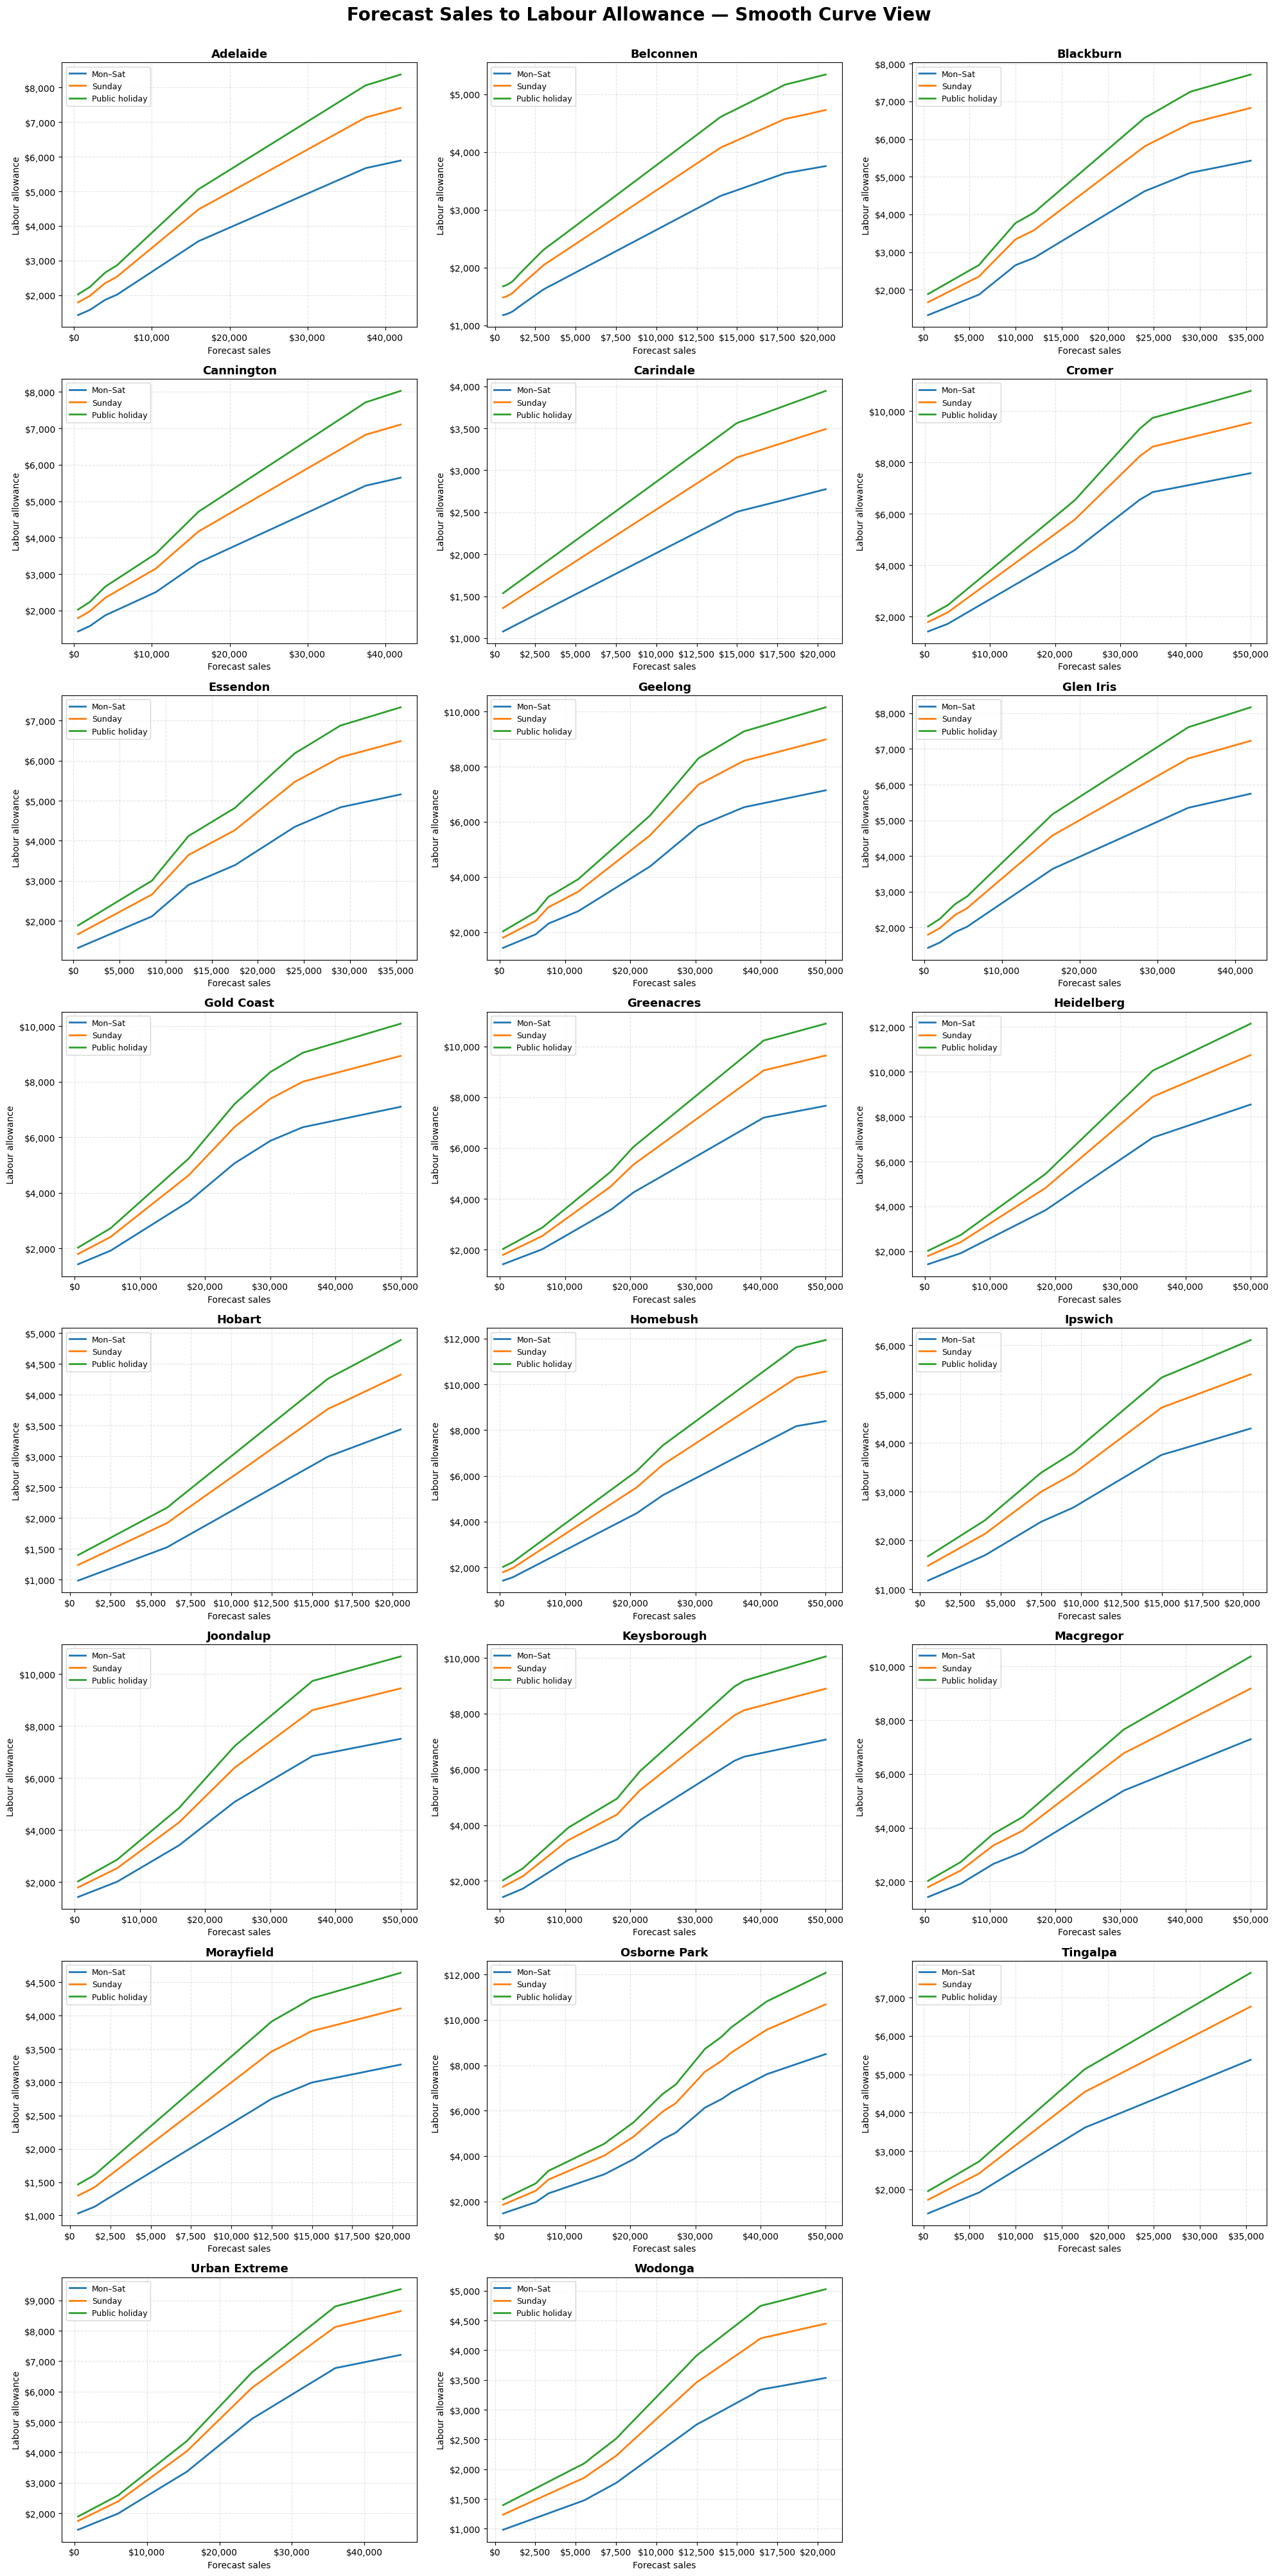

In [59]:
import matplotlib.pyplot as plt
import math
from matplotlib.ticker import StrMethodFormatter

# ---------------------------------------------------------
# 1. Read the FY26 labour reference table
# ---------------------------------------------------------
labour_reference = pd.read_excel(
    file_path,
    sheet_name="Labour Ref Table FY26",
    usecols="A:E",
    engine="openpyxl"
)

labour_reference.columns = [
    "venue",
    "forecast_sales_band",
    "labour_mon_sat",
    "labour_sunday",
    "labour_public_holiday"
]

# ---------------------------------------------------------
# 2. Clean the data
# ---------------------------------------------------------
labour_reference["venue"] = (
    labour_reference["venue"]
    .astype("string")
    .str.strip()
)

numeric_columns = [
    "forecast_sales_band",
    "labour_mon_sat",
    "labour_sunday",
    "labour_public_holiday"
]

for column in numeric_columns:
    labour_reference[column] = pd.to_numeric(
        labour_reference[column],
        errors="coerce"
    )

labour_reference = labour_reference.dropna(
    subset=[
        "venue",
        "forecast_sales_band",
        "labour_mon_sat",
        "labour_sunday",
        "labour_public_holiday"
    ]
).copy()

# Remove duplicate venue/revenue bands, if present
labour_reference = (
    labour_reference
    .sort_values(
        ["venue", "forecast_sales_band"]
    )
    .drop_duplicates(
        subset=["venue", "forecast_sales_band"],
        keep="last"
    )
)

venues = sorted(
    labour_reference["venue"].unique()
)

print("Number of venues:", len(venues))

# ---------------------------------------------------------
# 1. Read the FY26 labour reference table
# ---------------------------------------------------------
labour_reference = pd.read_excel(
    file_path,
    sheet_name="Labour Ref Table FY26",
    usecols="A:E",
    engine="openpyxl"
)

labour_reference.columns = [
    "venue",
    "forecast_sales_band",
    "labour_mon_sat",
    "labour_sunday",
    "labour_public_holiday"
]

# ---------------------------------------------------------
# 2. Clean the data
# ---------------------------------------------------------
labour_reference["venue"] = (
    labour_reference["venue"]
    .astype("string")
    .str.strip()
)

numeric_columns = [
    "forecast_sales_band",
    "labour_mon_sat",
    "labour_sunday",
    "labour_public_holiday"
]

for column in numeric_columns:
    labour_reference[column] = pd.to_numeric(
        labour_reference[column],
        errors="coerce"
    )

labour_reference = labour_reference.dropna(
    subset=[
        "venue",
        "forecast_sales_band",
        "labour_mon_sat",
        "labour_sunday",
        "labour_public_holiday"
    ]
).copy()

labour_reference = (
    labour_reference
    .sort_values(["venue", "forecast_sales_band"])
    .drop_duplicates(
        subset=["venue", "forecast_sales_band"],
        keep="last"
    )
)

venues = sorted(labour_reference["venue"].unique())

# ---------------------------------------------------------
# 3. Plot layout: 3 charts per row
# ---------------------------------------------------------
charts_per_row = 3
number_of_rows = math.ceil(len(venues) / charts_per_row)

fig, axes = plt.subplots(
    number_of_rows,
    charts_per_row,
    figsize=(20, number_of_rows * 5)
)

axes = np.asarray(axes).reshape(-1)

# ---------------------------------------------------------
# 4. Draw one smooth chart for each venue
# ---------------------------------------------------------
for axis, venue in zip(axes, venues):

    venue_data = (
        labour_reference[
            labour_reference["venue"] == venue
        ]
        .sort_values("forecast_sales_band")
        .copy()
    )

    x = venue_data["forecast_sales_band"].to_numpy()

    line_data = {
        "Mon–Sat": venue_data["labour_mon_sat"].to_numpy(),
        "Sunday": venue_data["labour_sunday"].to_numpy(),
        "Public holiday": venue_data["labour_public_holiday"].to_numpy()
    }

    # Dense x grid for smooth plotting
    x_smooth = np.linspace(x.min(), x.max(), 400)

    for label, y in line_data.items():

        # Shape-preserving smooth interpolation
        interpolator = PchipInterpolator(x, y)
        y_smooth = interpolator(x_smooth)

        axis.plot(
            x_smooth,
            y_smooth,
            linewidth=2,
            label=label
        )

        # # Optional: show original lookup points
        # axis.plot(
        #     x,
        #     y,
        #     marker="o",
        #     linestyle="None",
        #     markersize=3
        # )

    axis.set_title(
        venue,
        fontsize=13,
        fontweight="bold"
    )

    axis.set_xlabel("Forecast sales")
    axis.set_ylabel("Labour allowance")

    axis.xaxis.set_major_formatter(
        StrMethodFormatter("${x:,.0f}")
    )

    axis.yaxis.set_major_formatter(
        StrMethodFormatter("${x:,.0f}")
    )

    axis.grid(
        True,
        linestyle="--",
        alpha=0.35
    )

    axis.legend(
        fontsize=9,
        loc="best"
    )

# Hide empty subplot spaces
for axis in axes[len(venues):]:
    axis.set_visible(False)

fig.suptitle(
    "Forecast Sales to Labour Allowance — Smooth Curve View",
    fontsize=20,
    fontweight="bold",
    y=1.002
)

fig.tight_layout()
show_result_summary(
    title="Forecast Sales to Labour Allowance",
    purpose=(
        "Visualises how forecast sales are converted into labour "
        "allowances using the FY26 labour reference table."
    ),
    output=(
        "Three labour-allowance curves for each venue: Monday to "
        "Saturday, Sunday and public holiday."
    ),
    interpretation=(
        "Higher forecast sales generally produce a higher permitted "
        "labour allowance. Sunday and public-holiday labour values "
        "are usually higher because of penalty rates."
    ),
    note=(
        "The smooth curves are visual approximations. The workbook's "
        "actual calculation uses discrete sales bands and stepped "
        "lookup values."
    )
)
plt.show()

In [60]:

# =========================================================
# 1. Select which forecast labour allowance to compare
# =========================================================
# Options:
# "budget_labour"
# "conservative_labour"
# "revised_labour"

forecast_allowance_column = "revised_labour"
forecast_allowance_name = "Forecast Labour Allowance"


# =========================================================
# 2. Read actual labour
# =========================================================
# Actual Sales and Labour sheet:
# B = Date
# C = Venue
# E = Actual Labour

actual_labour = pd.read_excel(
    file_path,
    sheet_name="Actual Sales and Labour",
    usecols="B,C,E",
    header=None,
    names=[
        "date",
        "venue",
        "actual_labour"
    ],
    engine="openpyxl"
)

actual_labour["date"] = convert_mixed_excel_dates(
    actual_labour["date"]
)

actual_labour["venue"] = clean_venue(
    actual_labour["venue"]
)

actual_labour["actual_labour"] = pd.to_numeric(
    actual_labour["actual_labour"],
    errors="coerce"
)

actual_labour = actual_labour.dropna(
    subset=[
        "date",
        "venue",
        "actual_labour"
    ]
).copy()

actual_labour = actual_labour[
    actual_labour["venue"] != ""
]

# Combine duplicate venue/date rows
actual_labour = (
    actual_labour
    .groupby(
        ["venue", "date"],
        as_index=False
    )
    .agg(
        actual_labour=("actual_labour", "sum")
    )
)


# =========================================================
# 3. Prepare forecast allowance and ENTO labour
# =========================================================
labour_comparison = (
    comparison[
        [
            "venue",
            "date",
            forecast_allowance_column,
            "ento_roster"
        ]
    ]
    .rename(
        columns={
            forecast_allowance_column:
                "forecast_labour_allowance",

            "ento_roster":
                "ento_labour"
        }
    )
    .merge(
        actual_labour,
        on=[
            "venue",
            "date"
        ],
        how="inner"
    )
)


# =========================================================
# 4. Keep a common comparison period
# =========================================================
# Only dates where Forecast, ENTO and Actual labour all exist
labour_comparison = labour_comparison.dropna(
    subset=[
        "forecast_labour_allowance",
        "ento_labour",
        "actual_labour"
    ]
).copy()

if labour_comparison.empty:
    raise ValueError(
        "No common venue-date records contain "
        "forecast allowance, ENTO labour and actual labour."
    )


# =========================================================
# 5. Calculate differences for each date
# =========================================================
labour_comparison["forecast_difference"] = (
    labour_comparison["forecast_labour_allowance"]
    - labour_comparison["actual_labour"]
)

labour_comparison["ento_difference"] = (
    labour_comparison["ento_labour"]
    - labour_comparison["actual_labour"]
)


# =========================================================
# 6. Summarise each venue
# =========================================================
def calculate_labour_comparison(group, venue_name):

    actual_total = group["actual_labour"].sum()

    forecast_total = (
        group["forecast_labour_allowance"].sum()
    )

    ento_total = group["ento_labour"].sum()

    denominator = (
        group["actual_labour"]
        .abs()
        .sum()
    )

    forecast_difference = (
        forecast_total - actual_total
    )

    ento_difference = (
        ento_total - actual_total
    )

    if denominator == 0:
        forecast_bias = np.nan
        ento_bias = np.nan
    else:
        forecast_bias = (
            forecast_difference
            / denominator
        )

        ento_bias = (
            ento_difference
            / denominator
        )

    start_date = group["date"].min()
    end_date = group["date"].max()

    return {
        "Venue": venue_name,

        "Actual Labour": actual_total,

        forecast_allowance_name:
            forecast_total,

        "Forecast Difference":
            forecast_difference,

        "Forecast Bias":
            forecast_bias,

        "ENTO Labour":
            ento_total,

        "ENTO Difference":
            ento_difference,

        "ENTO Bias":
            ento_bias,

        "Days":
            group["date"].nunique(),

        "Date Range": (
            start_date.strftime("%d %b %Y")
            + " – "
            + end_date.strftime("%d %b %Y")
        )
    }


summary_rows = []

for venue, venue_data in labour_comparison.groupby(
    "venue",
    sort=True
):
    summary_rows.append(
        calculate_labour_comparison(
            venue_data,
            venue
        )
    )


# =========================================================
# 7. Add pooled ALL row
# =========================================================
summary_rows.append(
    calculate_labour_comparison(
        labour_comparison,
        "ALL"
    )
)

labour_comparison_summary = pd.DataFrame(
    summary_rows
)


# =========================================================
# 8. Keep ALL at the bottom
# =========================================================
venue_rows = (
    labour_comparison_summary[
        labour_comparison_summary["Venue"] != "ALL"
    ]
    .sort_values("Venue")
)

all_row = labour_comparison_summary[
    labour_comparison_summary["Venue"] == "ALL"
]

labour_comparison_summary = pd.concat(
    [
        venue_rows,
        all_row
    ],
    ignore_index=True
)


# =========================================================
# 9. Display
# =========================================================
show_result_summary(
    title="Forecast, ENTO and Actual Labour Comparison",
    purpose=(
        "Compares forecast labour allowance and ENTO rostered labour "
        "with the labour cost that actually occurred."
    ),
    output=(
        "Actual labour, forecast labour allowance, ENTO labour, "
        "their dollar differences from actual labour, and their biases."
    ),
    formula=(
        "Forecast bias = Σ(Forecast allowance − Actual labour) ÷ Σ|Actual labour|"
        "<br>"
        "ENTO bias = Σ(ENTO labour − Actual labour) ÷ Σ|Actual labour|"
    ),
    interpretation=(
        "Positive bias means forecast allowance or ENTO labour was "
        "above actual labour. Negative bias means it was below actual labour."
    ),
    note=(
        "The default forecast allowance uses Revised forecast sales. "
        "Budget or Conservative forecast labour can be selected instead."
    )
)

def highlight_all_row(row):
    if row["Venue"] == "ALL":
        return [
            "background-color: #e0e7ff;"
            "font-weight: bold;"
        ] * len(row)

    return [""] * len(row)


display(
    labour_comparison_summary.style
    .format(
        {
            "Actual Labour": "${:,.0f}",

            forecast_allowance_name:
                "${:,.0f}",

            "Forecast Difference":
                "${:+,.0f}",

            "Forecast Bias":
                "{:+.1%}",

            "ENTO Labour":
                "${:,.0f}",

            "ENTO Difference":
                "${:+,.0f}",

            "ENTO Bias":
                "{:+.1%}"
        },
        na_rep="—"
    )
    .apply(
        highlight_all_row,
        axis=1
    )
    .hide(axis="index")
)

Venue,Actual Labour,Forecast Labour Allowance,Forecast Difference,Forecast Bias,ENTO Labour,ENTO Difference,ENTO Bias,Days,Date Range
Adelaide,"$93,992","$113,715","$+19,723",+21.0%,"$86,190","$-7,802",-8.3%,30,04 Jul 2025 – 02 Aug 2025
Belconnen,"$70,440","$86,112","$+15,672",+22.2%,"$71,851","$+1,411",+2.0%,31,04 Jul 2025 – 03 Aug 2025
Blackburn,"$88,161","$91,476","$+3,315",+3.8%,"$75,914","$-12,247",-13.9%,31,04 Jul 2025 – 03 Aug 2025
Cannington,"$109,607","$120,317","$+10,710",+9.8%,"$95,775","$-13,832",-12.6%,31,04 Jul 2025 – 03 Aug 2025
Carindale,"$41,355","$53,335","$+11,980",+29.0%,"$41,198",$-157,-0.4%,31,04 Jul 2025 – 03 Aug 2025
Cromer,"$79,199","$104,947","$+25,748",+32.5%,"$78,773",$-426,-0.5%,31,04 Jul 2025 – 03 Aug 2025
Essendon,"$93,181","$98,419","$+5,238",+5.6%,"$86,211","$-6,970",-7.5%,31,04 Jul 2025 – 03 Aug 2025
Geelong,"$95,237","$106,484","$+11,247",+11.8%,"$94,304",$-933,-1.0%,31,04 Jul 2025 – 03 Aug 2025
Glen Iris,"$87,926","$109,301","$+21,375",+24.3%,"$85,794","$-2,132",-2.4%,31,04 Jul 2025 – 03 Aug 2025
Gold Coast,"$104,384","$100,266","$-4,118",-3.9%,"$92,352","$-12,032",-11.5%,27,04 Jul 2025 – 30 Jul 2025
